### **CPU Matrix Multiplication 1**

In [16]:
import numpy as np
from numba import jit

@jit(nopython=True)
def matmul(A, B):
    C = np.zeros((A.shape[0],B.shape[1]))
    for i in range(A.shape[0]):
        for j in range(B.shape[1]):
            for k in range(A.shape[1]):
                C[i,j] += A[i,k] * B[k,j]
    return C

### **CPU Matrix Multiplication 2**

In [17]:
import time

start = time.time()
A = np.random.rand(100, 100)
B = np.random.rand(100, 100)

matmul(A, B)
print("Time taken: ", time.time() - start)

Time taken:  0.07614016532897949


NORMAL version takes $0.27$ seconds, meanwhile JIT compiled version takes $0.076$ seconds.

### **CPU Matrix Multiplication 3**

In [ ]:
import numpy as np
from numba import jit

@jit(nopython=True)
def matmul(A, B):
    C = np.zeros((A.shape[0],B.shape[1]))
    for i in range(A.shape[0]):
        for j in range(B.shape[1]):
            for k in range(A.shape[1]):
                C[i,j] += A[i,k] * B[k,j]
    return C

So outer most is i, middle is j and inner most is k.

### **CPU Matrix Multiplication 4**

In [22]:
start = time.time()
A = np.random.rand(200, 200)
B = np.random.rand(200, 200)

matmul(A, B)
print("Time taken: ", time.time() - start)

Time taken:  0.00779414176940918


It is just as fast as the previous one EVEN though we have matrices that are $4$ times larger.

### **CPU Matrix Multiplication 5**

Matrices for $N \times N$ matrices use $2n^3 \text{FLOPs}$, and each matrix has $N^2$ elements and each element is 8 bytes aka float64 so:
```python
size_bytes = 3 * n * n * 8
size_kb = size_bytes / 1024
```
Below is a fully running code.

In [23]:
sizes = np.arange(20, 2001, 100)

mflops_list = []
size_kb_list = []

# TEST
A = np.random.rand(50, 50)
B = np.random.rand(50, 50)
matmul(A, B)
# TEST

for n in sizes:
    A = np.random.rand(n, n)
    B = np.random.rand(n, n)

    start = time.time()
    matmul(A, B)
    end = time.time()

    elapsed = end - start

    flops = 2 * n**3
    mflops = flops / (elapsed * 1e6)

    size_bytes = 3 * n * n * 8
    size_kb = size_bytes / 1024

    mflops_list.append(mflops)
    size_kb_list.append(size_kb)

Text(0.5, 1.0, 'Matrix multiplication performance')

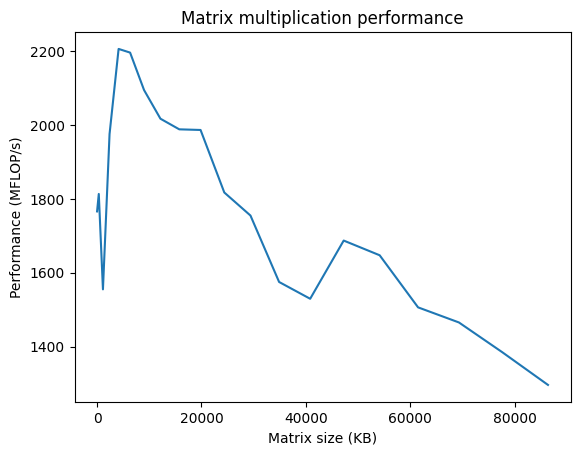

In [25]:
from matplotlib import pyplot as plt

plt.plot(size_kb_list, mflops_list)
plt.xlabel("Matrix size (KB)")
plt.ylabel("Performance (MFLOP/s)")
plt.title("Matrix multiplication performance")

WE also mark cache sizes.

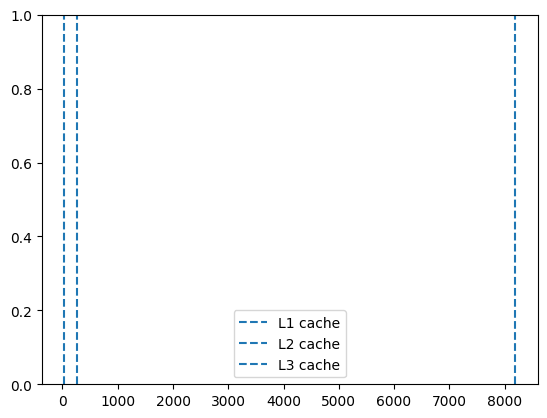

In [27]:
plt.axvline(32, linestyle='--', label='L1 cache')
plt.axvline(256, linestyle='--', label='L2 cache')
plt.axvline(8192, linestyle='--', label='L3 cache')
plt.legend()
plt.show()

### **CUDA Vector Addition 1**

In [ ]:
from numba import cuda

@cuda.jit
def add_kernel(x, y, out):
    i = cuda.grid(1)
    if i < out.size:
        out[i] = x[i] + y[i]

We must add `if i < out.size` to avoid out of bounds error when the number of threads is out of bounds, like if we get $i=3$ but then we cannot access `out[3]` if the size of `out` is only from $0$ to $2$.

### **CUDA Vector Addition 2**

In [ ]:
import numpy as np
import time
from numba import cuda

# ------------------------
# CUDA kernel
# ------------------------
@cuda.jit
def add_kernel(x, y, out):
    i = cuda.grid(1)
    if i < out.size:
        out[i] = x[i] + y[i]

# ------------------------
# Main program
# ------------------------
def main():
    N = 1_000_000

    # Create input data
    x = np.random.rand(N).astype(np.float32)
    y = np.random.rand(N).astype(np.float32)

    # Allocate output
    out = np.zeros_like(x)

    # Copy to GPU
    d_x = cuda.to_device(x)
    d_y = cuda.to_device(y)
    d_out = cuda.device_array_like(out)

    # Configure kernel
    threads_per_block = 256
    blocks = (N + threads_per_block - 1) // threads_per_block

    # ------------------------
    # Warm-up (JIT compilation)
    # ------------------------
    add_kernel[blocks, threads_per_block](d_x, d_y, d_out)
    cuda.synchronize()

    # ------------------------
    # Timing
    # ------------------------
    start = time.time()

    add_kernel[blocks, threads_per_block](d_x, d_y, d_out)
    cuda.synchronize()   # VERY IMPORTANT

    end = time.time()

    # Copy result back (optional, but good practice)
    result = d_out.copy_to_host()

    print("Execution time (seconds):", end - start)

if __name__ == "__main__":
    main()

### **CUDA Vector Addition 3**

See .sh file.

### **CUDA Vector Addition 4**

We just have to change to have this:
```python
from numba import cuda

x = cuda.pinned_array(N, dtype=np.float32)
y = cuda.pinned_array(N, dtype=np.float32)
```

### **CUDA Vector Addition 5**

In order to solve this exercise, we just have to have:
```python
# Copy ONCE (outside timing)
d_x = cuda.to_device(x)
d_y = cuda.to_device(y)
d_out = cuda.device_array_like(x)

# Warm-up
add_kernel[blocks, threads](d_x, d_y, d_out)
cuda.synchronize()

# Timing ONLY kernel
start = time.time()

add_kernel[blocks, threads](d_x, d_y, d_out)
cuda.synchronize()

end = time.time()

print("Kernel time:", end - start)
```

### **CUDA Matrix Multiplication 1**

In [ ]:
from numba import cuda

@cuda.jit
def matmul_kernel(A, B, C):
    row, col = cuda.grid(2)
    if row < C.shape[0] and col < C.shape[1]:
        tmp = 0
        for k in range(A.shape[1]):
            tmp += A[row, k] * B[k, col]
        C[row, col] = tmp

A temporary variable is used to accumulate results in registers, reducing expensive global memory accesses. Writing directly to `C[row, col]` would require repeated reads and writes to global memory inside the loop, significantly degrading performance.

### **CUDA Matrix Multiplication 2**

TO BE DONE

### **CUDA Matrix Multiplication 3**

TO BE DONE

### **CUDA Matrix Multiplication 4**

TO BE DONE